# Описание датасета

Датасет содержит 50 снимков микроструктуры сплавов двух смесей металлов после [SPS-спекация](https://en.wikipedia.org/wiki/Spark_plasma_sintering) в разные моменты времени (от 5 до 25 минут). Снимки созданы системой электронного микроскопа и имеют формат TIF.

Размер: 1024х768 пикселей

Для каждого изображения вручную была создана маска, сохранённая в формате PNG. Маски содержат следующий метки классов:
- 1 — сталь Э76;
- 2 — переходный слой.
- 3 — сталь 12Х18Н10Т.

Маски могут содержать метку 0 - ошибка разметки (соответствующий пиксель был пропущен при разметке).

Датасет разделён на обучающую (40 изображений) и валидационную (10 изображений) выборки.

# Импорт библиотек

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from pathlib import Path

# Импорт и визуализация датасета

In [56]:
CLASSES = 3
IMG_SHAPE = (1024, 768)

DATASET_PATH = Path('./dataset/train')
IMAGES_PATH = DATASET_PATH / 'imgPNG'
MASKS_PATH = DATASET_PATH / 'mask'
IMG_EXT = "*.png"
MSK_EXT = "*.png"

image_filenames = sorted(glob(os.path.join(IMAGES_PATH, IMG_EXT)))
mask_filenames  = sorted(glob(os.path.join(MASKS_PATH, MSK_EXT)))

if len(image_filenames) != len(mask_filenames):
    raise Exception('The number of images and masks is different')

print(f"Number of samples: {len(image_filenames)}")

Number of samples: 40


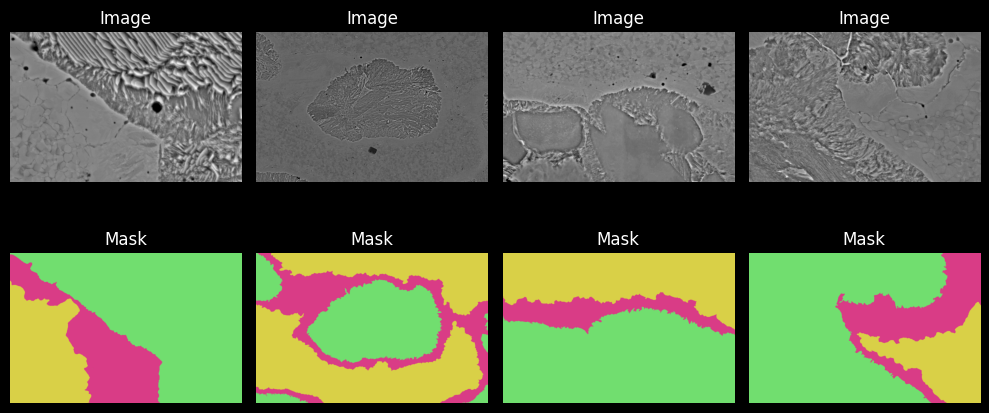

In [43]:
CLASS_COLORS = {
    1: [113, 222, 111],
    2: [217, 60, 134],
    3: [217, 208, 71]
}

def getColorMask(mask):
    mask_rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for i in range(CLASSES):
        mask_rgb[mask==i+1]=np.array(CLASS_COLORS[i+1])
    return mask_rgb

def load_image(path):
    return cv2.imread(path, cv2.IMREAD_GRAYSCALE)

def load_mask(path):
    return cv2.imread(path, cv2.IMREAD_UNCHANGED)

indices = np.random.choice(len(image_filenames), size=4, replace=False)

plt.figure(figsize=(10, 5))

for i, idx in enumerate(indices):
    img = load_image(image_filenames[idx])
    mask = load_mask(mask_filenames[idx])

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(2, 4, i + 5)
    plt.imshow(getColorMask(mask))
    plt.title("Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Анализ датасета

## Распределение классов

Посмотрим распределение классов по датасету

In [67]:
from collections import defaultdict

class_counts = defaultdict(int)

for mask_path in mask_filenames:
    mask = load_mask(mask_path)
    unique, counts = np.unique(mask, return_counts=True)
    for u, c in zip(unique, counts):
        class_counts[int(u)] += int(c)

total_pixels = sum(class_counts.values())
class_percent = {k: v / total_pixels * 100 for k, v in class_counts.items()}

print("Class distribution")
for k in sorted(class_percent.keys()):
    print(f"Class {k}: {class_percent[k]:.2f}%")

Class distribution
Class 0: 0.00%
Class 1: 52.69%
Class 2: 14.12%
Class 3: 33.19%


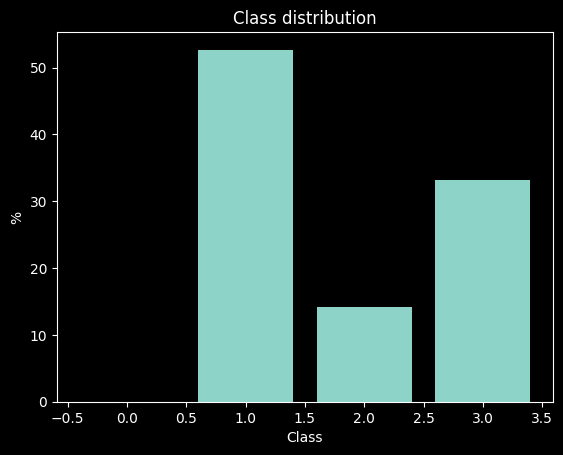

In [52]:
plt.bar(class_percent.keys(), class_percent.values())
plt.title("Class distribution")
plt.xlabel("Class")
plt.ylabel("%")
plt.show()

### Вывод

Как видно по графику, переходный слой занимает малую долю пикселей (<15%).

Это означает, что в датасете сильный дисбаланс классов и стандартная функция потерь кросс-энтропия может плохо работать. Требуется использование специальных функций потерь (например, фокусная кросс-энтропия).

## Площадь переходного слоя

In [76]:
from functools import reduce
from operator import mul

areas = []
pixels_on_image = reduce(mul, IMG_SHAPE)

for filename in mask_filenames:
    mask = load_mask(filename)
    area = np.sum(mask == 2)
    areas.append(area)

areas = np.array(areas) / pixels_on_image * 100

print("Transition layer area")
print(f"Min: {areas.min() :.3f}%")
print(f"Q1: {np.quantile(areas, 0.25):.3f} %")
print(f"Median: {np.median(areas):.3f} %")
print(f"Q3: {np.quantile(areas, 0.75):.3f} %")
print(f"Max: {areas.max():.3f} %")

Transition layer area
Min: 2.570%
Q1: 6.398 %
Median: 9.902 %
Q3: 17.105 %
Max: 31.968 %


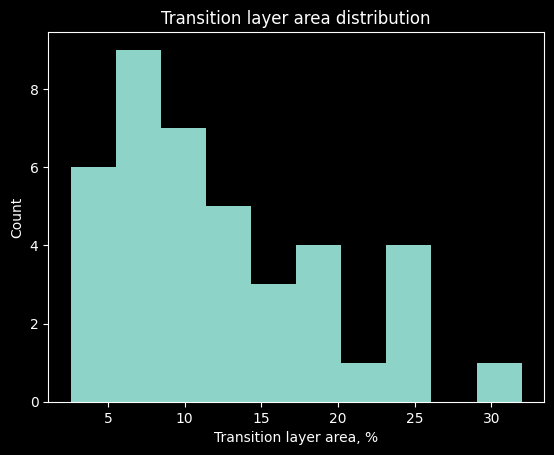

In [77]:
plt.hist(areas, bins=10)
plt.title("Transition layer area distribution")
plt.xlabel("Transition layer area, %")
plt.ylabel("Count")
plt.show()

### Вывод

Переходный слой занимает небольшую долю на снимках (в среднем около 10%). В большинстве случаев переходный слой относительно тонкий (в основном от 6 до 17%), но встречаются изображения с существенно более широкой областью (до 32%).

Для изображений, где переходный слой совсем тонкий и занимает малую площадь изображения, метрика IoU может быть недостаточно показательной, так как она чувствительна к ошибкам для маленьких объектов.

# Общие выводы

1. Присутствует проблема сильного дисбаланса класса. Требуется использование специальных функций потерь
2. Переходный слой в большинстве случаев совсем небольшой на снимках. Метрика IoU может быть недостаточно показательной. Требуется использование дополнительных метрик.